In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

In [5]:
data={
    "Study_hours":[1,2,3,4,5,6,7,8,9,10],
    "Sleep_hours":[8, 7, 6, 6, 5, 5, 4, 4, 3, 4],
    "Pass":[0,0,0,0,1,1,1,1,1,1]
}

In [6]:
data

{'Study_hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'Sleep_hours': [8, 7, 6, 6, 5, 5, 4, 4, 3, 4],
 'Pass': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]}

In [7]:
df=pd.DataFrame(data)
print(df.head())
print(df.info())
print(df.describe())

   Study_hours  Sleep_hours  Pass
0            1            8     0
1            2            7     0
2            3            6     0
3            4            6     0
4            5            5     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_hours  10 non-null     int64
 1   Sleep_hours  10 non-null     int64
 2   Pass         10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes
None
       Study_hours  Sleep_hours       Pass
count     10.00000    10.000000  10.000000
mean       5.50000     5.200000   0.600000
std        3.02765     1.549193   0.516398
min        1.00000     3.000000   0.000000
25%        3.25000     4.000000   0.000000
50%        5.50000     5.000000   1.000000
75%        7.75000     6.000000   1.000000
max       10.00000     8.000000   1.000000


In [8]:
print(df.isnull().sum())

Study_hours    0
Sleep_hours    0
Pass           0
dtype: int64


In [9]:
df=df.dropna()

In [10]:
df=df.drop_duplicates()

In [11]:
df

,Study_hours,Sleep_hours,Pass
0,1,8,0
1,2,7,0
2,3,6,0
3,4,6,0
4,5,5,1
5,6,5,1
6,7,4,1
7,8,4,1
8,9,3,1
9,10,4,1


In [12]:
import matplotlib.pyplot as plt

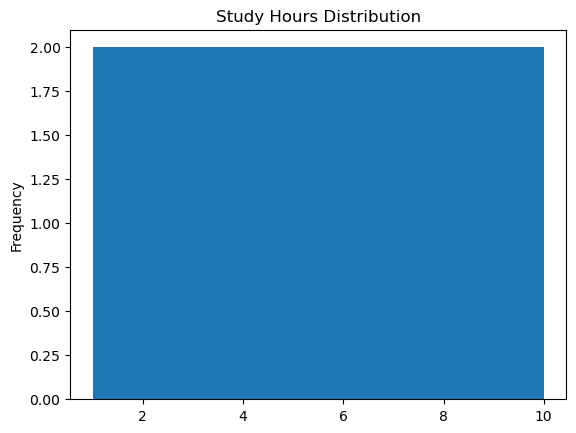

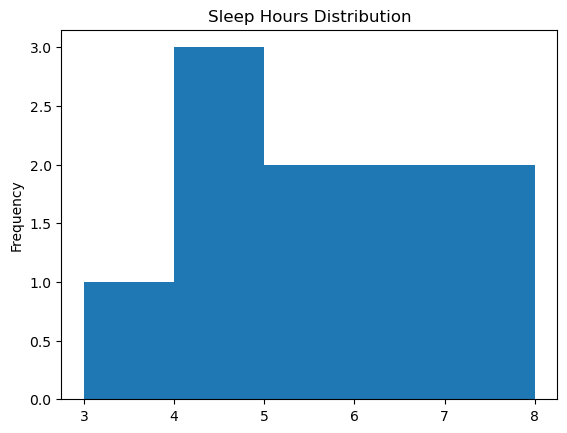

In [14]:
df["Study_hours"].plot(kind="hist",bins=5,title="Study Hours Distribution")
plt.show()
df["Sleep_hours"].plot(kind="hist",bins=5,title="Sleep Hours Distribution")
plt.show()    

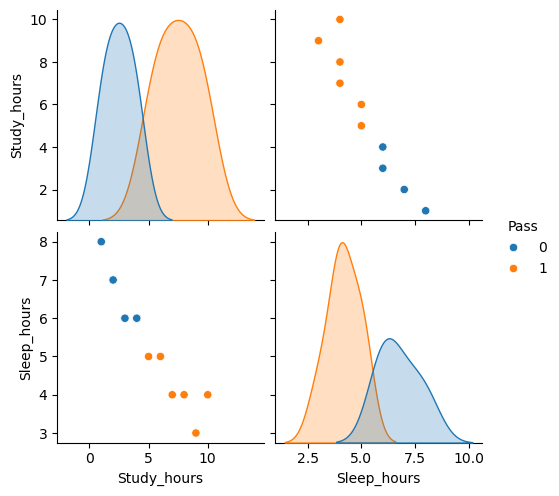

In [15]:
import seaborn as sns
sns.pairplot(df,hue="Pass")
plt.show()

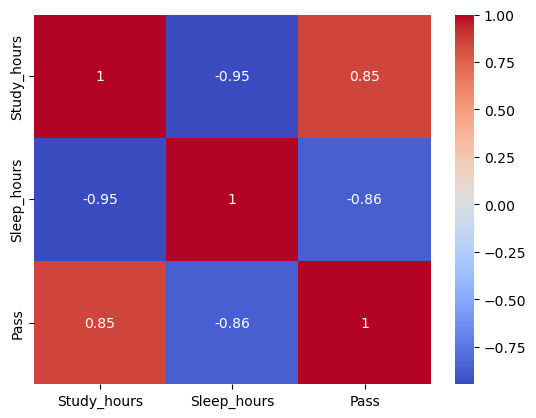

In [17]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [19]:
X=df[["Study_hours","Sleep_hours"]]

In [20]:
y=df[["Pass"]]

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [25]:
model=RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train_scaled,y_train)

C:\Users\spectrum\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test_scaled)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 1.0
